In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def extract_best(df):
    chosen_configurations = []
    for recall_cut in np.arange(0.9, 1.01, 0.01):
        chosen_configurations.append(df[df.Recall > recall_cut].sort_values("Query Time (microsecs)").head(1))
    df = pd.concat(chosen_configurations)
    return df


In [13]:
log_files = {
    "f16" : "/home/cosimorulli/next_develop_seismic/seismic_private/grid_search_cocondenser_2025-10-07_22:52:38.522921/building_combination_0_2025-10-07_22:52:38/report.tsv", 
    "f8" : "/home/cosimorulli/next_develop_seismic/seismic_private/grid_search_cocondenser_2025-10-07_22:22:29.689637/building_combination_0_2025-10-07_22:22:29/report.tsv", 
    "baseline_streamvbyte_f16": "/home/cosimorulli/next_develop_seismic/seismic_private/grid_search_cocondenser_baseline_streamvbyte_f16_2025-10-07_21:38:29.129492/building_combination_0_2025-10-07_21:38:29/report.tsv",
    "baseline_streamvbyte_f8" : "/home/cosimorulli/next_develop_seismic/seismic_private/grid_search_cocondenser_baseline_streamvbyte_f8_2025-10-07_21:00:48.684394/building_combination_0_2025-10-07_21:00:48/report.tsv", 
    "zeta_f16": "/home/cosimorulli/next_develop_seismic/seismic_private/grid_search_cocondenser_compression_f16_2025-10-08_01:31:14.946947/building_combination_0_2025-10-08_01:31:14/report.tsv",
    "zeta_f8": "/home/cosimorulli/next_develop_seismic/seismic_private/grid_search_cocondenser_compression_f8_2025-10-08_00:31:04.973622/building_combination_0_2025-10-08_00:31:04/report.tsv",
    "streamvbyte_f8": "/home/cosimorulli/next_develop_seismic/seismic_private/grid_search_cocondenser_streamvbyte_f8_2025-10-08_00:10:25.571494/building_combination_0_2025-10-08_00:10:25/report.tsv", 
    
       
    #"partitioned_f16" : "/home/cosimorulli/next_develop_seismic/martinos_patch/seismic_private/grid_search_cocondenser_partitioned_f16_2025-10-06_08:43:00.570205/building_combination_0_2025-10-06_08:43:00/report.tsv", 
    #"partitioned_f8": "/home/cosimorulli/next_develop_seismic/martinos_patch/seismic_private/grid_search_cocondenser_partitioned_f8_2025-10-06_09:14:14.626621/building_combination_0_2025-10-06_09:14:14/report.tsv",
    #"streamvbyte": "/home/cosimorulli/next_develop_seismic/martinos_patch/seismic_private/grid_search_cocondenser_streamvbyte_f8_2025-10-06_10:09:20.725532/building_combination_0_2025-10-06_10:09:20/report.tsv",
    #"streamvbyte-v2": "/home/cosimorulli/next_develop_seismic/martinos_patch/seismic_private/grid_search_cocondenser_streamvbyte_f8_diff_target_cpu_2025-10-06_14:35:22.031046/building_combination_0_2025-10-06_14:35:22/report.tsv"
}

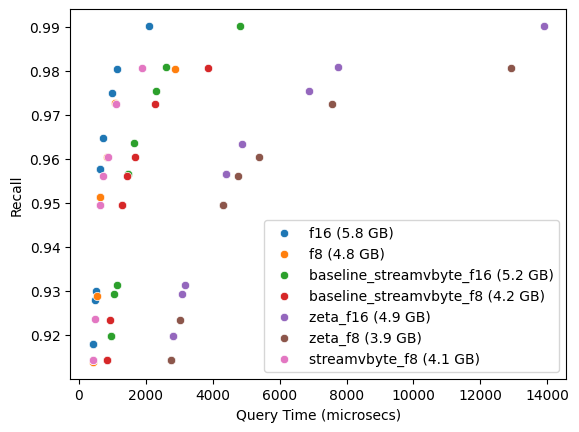

In [14]:
all_df = []

for name, file_path in log_files.items():
    current_df = extract_best(pd.read_csv(file_path, sep="\t"))
    mem_usage = current_df["Memory Usage (Bytes)"].values[0] / 1024**3
    current_df['name'] = name
    all_df.append(current_df)
    sns.scatterplot(data=current_df, x = "Query Time (microsecs)", y="Recall", label=f"{name} ({round(mem_usage, 1)} GB)")

plt.legend()
all_df = pd.concat(all_df)

In [10]:
all_df[all_df.name == 'partitioned_f8']

,Subsection,Query Time (microsecs),Recall,RR@10,Memory Usage (Bytes),Building Time (secs),name


In [45]:
all_df[all_df.name == 'streamvbyte']

,Subsection,Query Time (microsecs),Recall,RR@10,Memory Usage (Bytes),Building Time (secs),name
14,combination_15,431,0.914284,0.378359,4610633505,206,streamvbyte
14,combination_15,431,0.914284,0.378359,4610633505,206,streamvbyte
22,combination_23,487,0.923524,0.378490,4610633505,206,streamvbyte
13,combination_14,652,0.949470,0.380517,4610633505,206,streamvbyte
13,combination_14,652,0.949470,0.380517,4610633505,206,streamvbyte
20,combination_21,735,0.956175,0.380540,4610633505,206,streamvbyte
52,combination_53,879,0.960430,0.380618,4610633505,206,streamvbyte
19,combination_20,1133,0.972564,0.381893,4610633505,206,streamvbyte
32,combination_33,1920,0.980759,0.382002,4610633505,206,streamvbyte


In [4]:
old_streamvbyte = pd.read_csv("/home/cosimorulli/next_develop_seismic/martinos_patch/seismic_private/grid_search_cocondenser_streamvbyte_f8_2025-10-06_10:09:20.725532/building_combination_0_2025-10-06_10:09:20/report.tsv", sep="\t")
new_streamvbyte = pd.read_csv("/home/cosimorulli/next_develop_seismic/seismic_private/grid_search_cocondenser_streamvbyte_f8_diff_target_cpu_2025-10-07_13:15:03.176757/building_combination_0_2025-10-07_13:15:03/report.tsv", sep="\t")

<Axes: xlabel='Query Time (microsecs)', ylabel='Recall'>

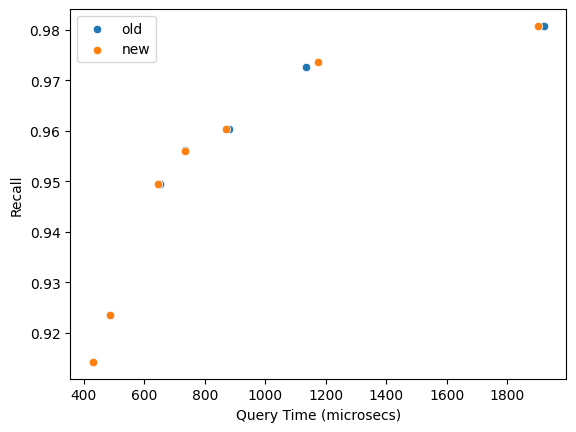

In [11]:
sns.scatterplot(data=extract_best(old_streamvbyte), x="Query Time (microsecs)", y="Recall", label="old")
sns.scatterplot(data=extract_best(new_streamvbyte), x="Query Time (microsecs)", y="Recall", label="new")


In [16]:
my_strm_path = "/home/cosimorulli/next_develop_seismic/seismic_private/grid_search_cocondenser_streamvbyte_f8_2025-10-08_09:06:22.660048/building_combination_0_2025-10-08_09:06:22/report.tsv"
my_strm = pd.read_csv(my_strm_path, sep="\t")

In [21]:
martino_strm_path = "/home/cosimorulli/next_develop_seismic/seismic_private/grid_search_cocondenser_streamvbyte_f8_2025-10-08_00:10:25.571494/building_combination_0_2025-10-08_00:10:25/report.tsv"
martino_strm = pd.read_csv(martino_strm_path, sep="\t")

In [22]:
my_strm["Query Time (microsecs)"] - martino_strm["Query Time (microsecs)"]

0     485
1       0
2       1
3       0
4      -1
5       0
6      -2
7      -3
8       2
9       2
10     -1
11      0
12      1
13      0
14     -1
15     -1
16      8
17     10
18      0
19      2
20      2
21      3
22      0
23     -7
24     -2
25     10
26      6
27      5
28      4
29      8
30      0
31      0
32     12
33      8
34      1
35      4
36      0
37      0
38      8
39     -3
40     11
41      7
42      5
43      5
44      0
45      1
46     -3
47     -4
48     18
49     16
50     12
51      9
52      3
53      3
54      2
55      2
Name: Query Time (microsecs), dtype: int64

In [19]:
my_strm.head(10)

,Subsection,Query Time (microsecs),Recall,RR@10,Memory Usage (Bytes),Building Time (secs)
0,combination_1,1635,0.935444,0.376245,4413832923,173
1,combination_2,1149,0.935444,0.376245,4413832923,173
2,combination_3,763,0.926533,0.376557,4413832923,173
3,combination_4,763,0.926533,0.376557,4413832923,173
4,combination_5,505,0.903166,0.374863,4413832923,173
5,combination_6,505,0.903166,0.374863,4413832923,173
6,combination_7,338,0.858367,0.370621,4413832923,173
7,combination_8,338,0.858367,0.370621,4413832923,173
8,combination_9,1520,0.974542,0.381854,4413832923,173
9,combination_10,1533,0.974542,0.381854,4413832923,173


In [23]:
martino_strm.head(10)

,Subsection,Query Time (microsecs),Recall,RR@10,Memory Usage (Bytes),Building Time (secs)
0,combination_1,1150,0.935444,0.376245,4413831309,182
1,combination_2,1149,0.935444,0.376245,4413831309,182
2,combination_3,762,0.926547,0.376545,4413831309,182
3,combination_4,763,0.926547,0.376545,4413831309,182
4,combination_5,506,0.903181,0.374863,4413831309,182
5,combination_6,505,0.903181,0.374863,4413831309,182
6,combination_7,340,0.858352,0.370621,4413831309,182
7,combination_8,341,0.858352,0.370621,4413831309,182
8,combination_9,1518,0.974542,0.381854,4413831309,182
9,combination_10,1531,0.974542,0.381854,4413831309,182
